# Homework 5 Problem 2: Swin Fine-Tuning vs. Scratch

**Course:** ECGR 5106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook reports the current Problem 2 experiment artifacts from `Results_Problem_2`. The completed pretrained rows are partial one-epoch runs; the scratch Swin row is a completed five-epoch CPU fallback using native 32 by 32 CIFAR-100 inputs.

## Experiment Setup

The pretrained Swin-Tiny and Swin-Small models are loaded with Hugging Face `SwinForImageClassification`, their classifier heads are replaced for 100 classes, and the backbone parameters are frozen so only the classifier head is trained. CIFAR-100 images are resized to 224 by 224 for the Swin inputs.

The scratch model uses `torchvision.models.swin_t(weights=None)` with a 100-class head and all parameters trainable. Because CUDA was not available in the verification session, the measured scratch run uses native 32 by 32 CIFAR-100 inputs, batch size 128, and a 5-epoch CPU schedule.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
RESULTS = ROOT / 'Results_Problem_2'
history_path = RESULTS / 'problem2_history.csv'
summary_path = RESULTS / 'problem2_summary.csv'
plot_path = RESULTS / 'problem2_training_curves.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Plot:', plot_path)

Summary: /home/gilberto/Homework_5/Results_Problem_2/problem2_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_2/problem2_history.csv
Plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_training_curves.png


## Summary Results

The table below is read directly from `Results_Problem_2/problem2_summary.csv`.

In [2]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,pretrained,frozen_backbone,total_parameter_count,parameter_count,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,swin_tiny_pretrained,True,True,27596254,76900.0,851.964052,3.293167,2.296862,60.56,device=cuda
1,swin_small_pretrained,True,True,48914158,76900.0,678.623637,3.131479,2.058130,64.74,device=cuda
2,swin_scratch,False,False,27596254,27596254.0,1244.409974,2.903061,2.802721,29.19,"device=cpu,image_size=32,batch_size=128"


## Clean Report Table

In [3]:
report_cols = [
    'model_name', 'pretrained', 'frozen_backbone', 'total_parameter_count', 'parameter_count',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Pretrained', 'Frozen Backbone', 'Total Params', 'Trainable Params', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Pretrained,Frozen Backbone,Total Params,Trainable Params,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,swin_tiny_pretrained,True,True,27596254,76900.0,851.964052,2.296862,60.56,device=cuda
1,swin_small_pretrained,True,True,48914158,76900.0,678.623637,2.058130,64.74,device=cuda
2,swin_scratch,False,False,27596254,27596254.0,1244.409974,2.802721,29.19,"device=cpu,image_size=32,batch_size=128"


## Per-Epoch History

A full Problem 2 run should produce about 15 data rows: 3 models times 5 epochs. The current history file has 7 rows: one completed epoch for each pretrained model and five completed CPU fallback epochs for scratch Swin.

In [4]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 7


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,swin_tiny_pretrained,1,3.293167,2.296862,43.946,60.56,851.962756
1,swin_small_pretrained,1,3.131479,2.058130,48.634,64.74,678.622131
2,swin_scratch,1,3.931522,3.612877,9.868,14.74,1452.259539
3,swin_scratch,2,3.460525,3.287901,16.254,19.76,1614.405993
4,swin_scratch,3,3.235671,3.155131,20.428,21.77,1402.996956
5,swin_scratch,4,3.055125,2.971835,23.618,25.72,859.719342
6,swin_scratch,5,2.903061,2.802721,26.840,29.19,892.665147


## Training Curves

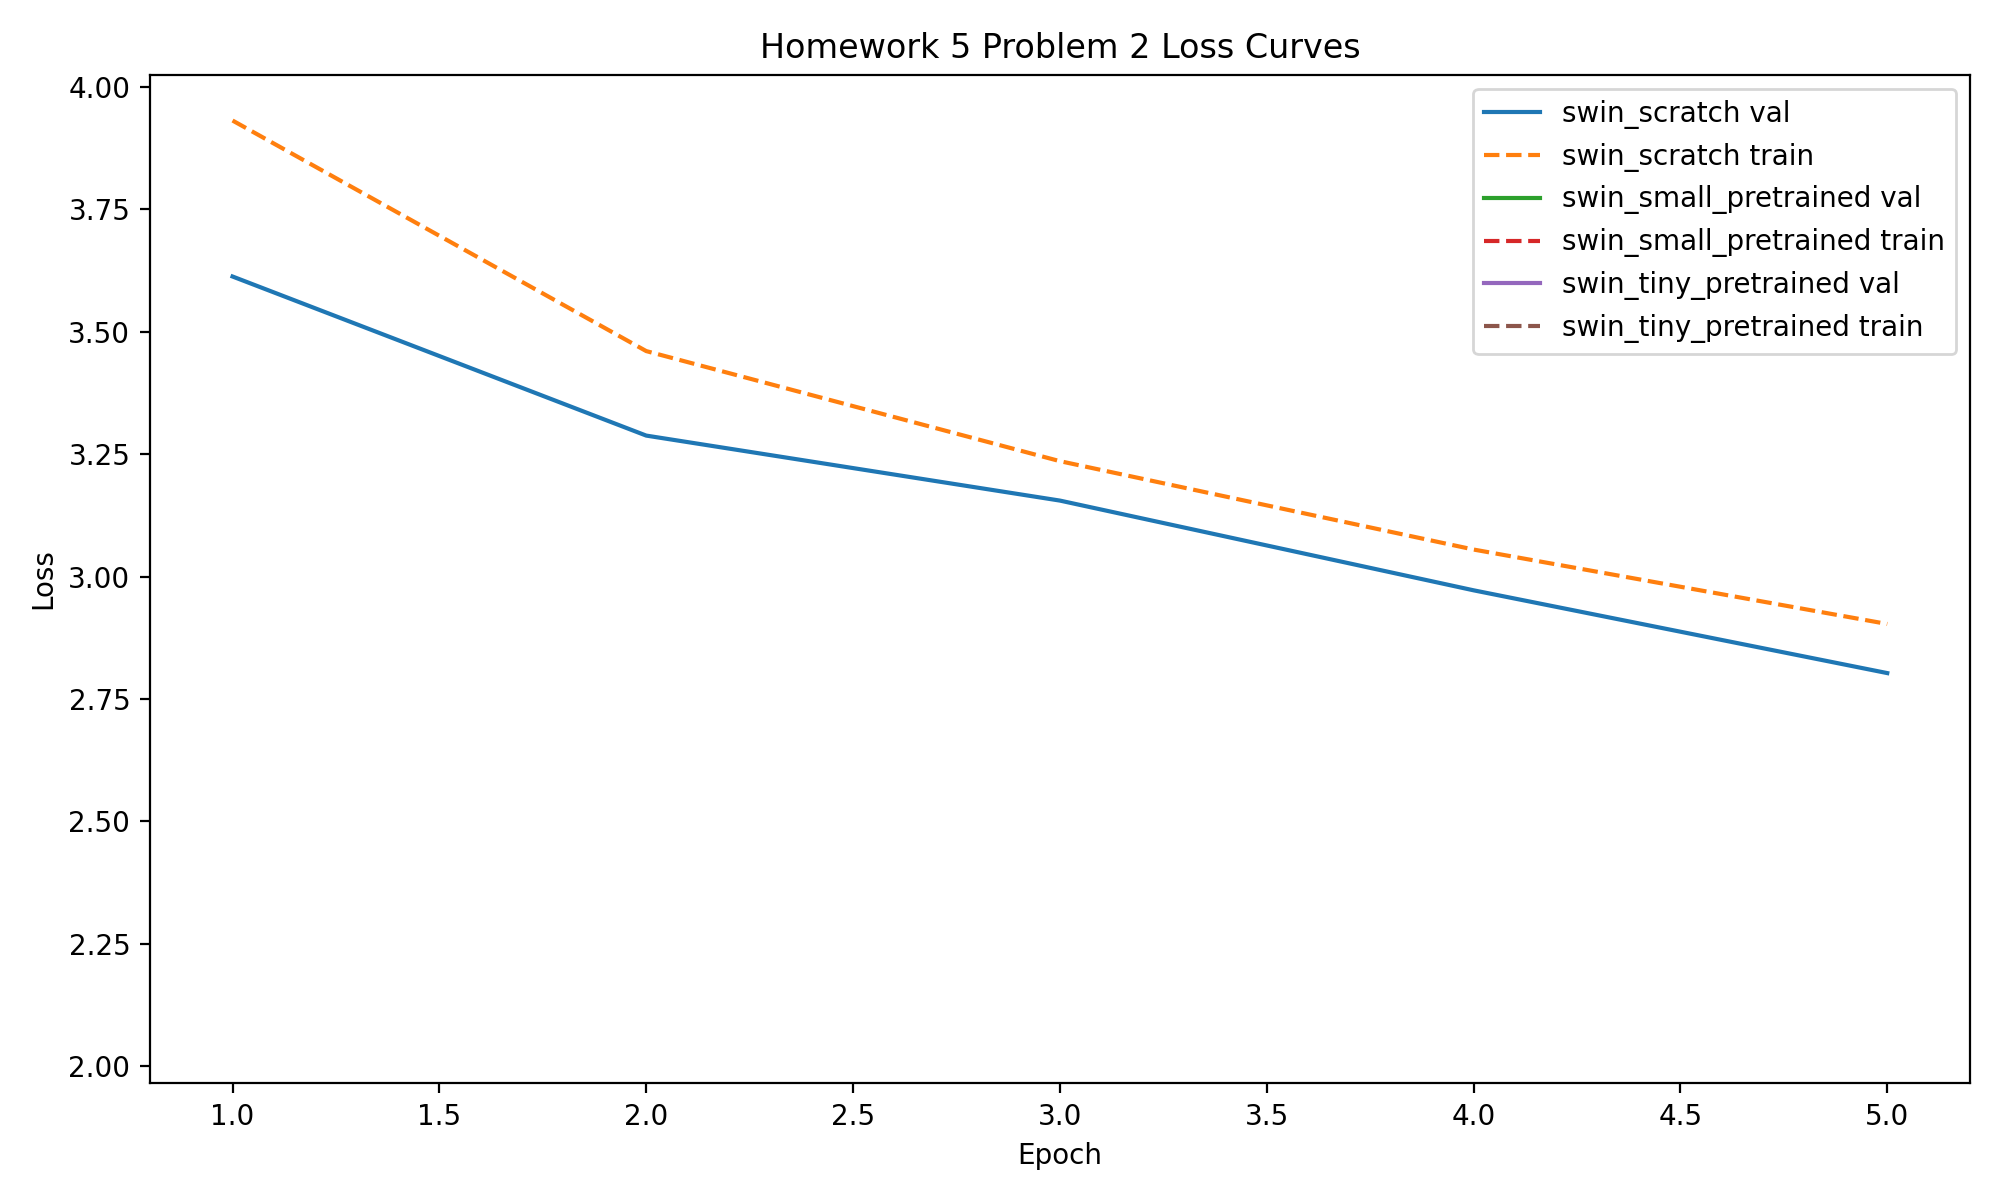

In [5]:
display(Image(filename=str(plot_path)))

## Interpretation

The completed pretrained rows show strong transfer-learning performance after one epoch. Swin-Tiny reaches 60.56% accuracy and Swin-Small reaches 64.74% accuracy. Swin-Small has the better validation loss and test accuracy in the current artifacts.

Scratch Swin reaches 29.19% accuracy after five CPU epochs using native 32 by 32 inputs. That is still much lower than the one-epoch pretrained Swin rows, which supports the transfer-learning advantage. The comparison is not perfectly controlled because the pretrained rows used 224 by 224 inputs and CUDA while scratch used 32 by 32 inputs and CPU timing.